In [2]:
import pandas as pd
import google.generativeai as genai
from google.cloud import bigquery
import matplotlib.pyplot as plt
import plotly.express as px
from dotenv import load_dotenv

print("All packages installed successfully!")

C:\Users\asus\AppData\Local\Temp\ipykernel_12208\1673893884.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


All packages installed successfully!


In [28]:
import streamlit as st

In [3]:
from gemini_helper import ask_gemini

response = ask_gemini(
    "Explain what total revenue means in ecommerce."
)

print(response)

In e-commerce, **Total Revenue** is the **total amount of money an online business generates from the sale of its goods or services before any expenses or deductions are taken out.**

It's the "top-line" number on an income statement and represents the full value of all sales transactions over a specific period (e.g., a day, week, month, quarter, or year).

Here's a breakdown of what that means in an e-commerce context:

1.  **Core Calculation:**
    *   It's essentially the sum of (Price of Product/Service * Quantity Sold) for all items sold.
    *   **Example:** If an e-commerce store sells 100 t-shirts at $20 each and 50 hats at $15 each in a month:
        *   T-shirt revenue: 100 * $20 = $2,000
        *   Hat revenue: 50 * $15 = $750
        *   **Total Revenue = $2,000 + $750 = $2,750**

2.  **What's Usually Included:**
    *   **Product Sales:** The price customers pay for physical or digital products.
    *   **Service Sales:** If the e-commerce business offers subscriptions, 

In [4]:
from gemini_helper import ask_gemini
from sql_prompt import SYSTEM_PROMPT

question = "What is the total revenue generated?"

prompt = SYSTEM_PROMPT + "\n\nQuestion: " + question

sql_query = ask_gemini(prompt)

print(sql_query)

SELECT
    SUM(t1.price)
FROM
    ecommerce_raw.order_items AS t1


In [5]:
from bigquery_helper import run_query

df = run_query(sql_query)

df

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,f0_
0,1.359164e+07


In [6]:
question = "Count orders by status"

In [7]:
df = run_query(sql_query)
df

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,f0_
0,1.359164e+07


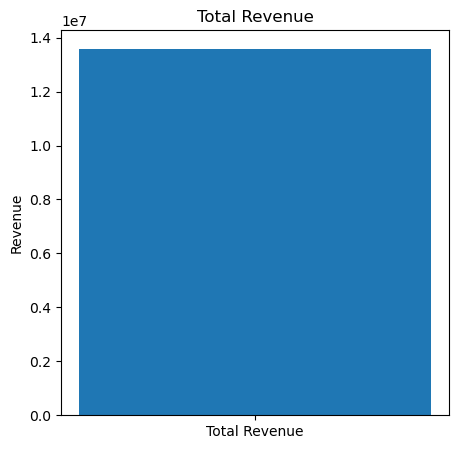

In [8]:
from charts import revenue_chart

revenue_chart(df)

In [9]:
query = """
SELECT
    order_status,
    COUNT(*) AS num_orders
FROM ecommerce_raw.orders
GROUP BY order_status
"""

In [10]:
df = run_query(query)
df

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_status,num_orders
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


In [11]:
query = """
SELECT
FORMAT_DATE('%Y-%m', DATE(order_purchase_timestamp)) AS month,
SUM(payment_value) AS revenue
FROM ecommerce_raw.orders o
JOIN ecommerce_raw.order_payments p
ON o.order_id = p.order_id
GROUP BY month
ORDER BY month
"""

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


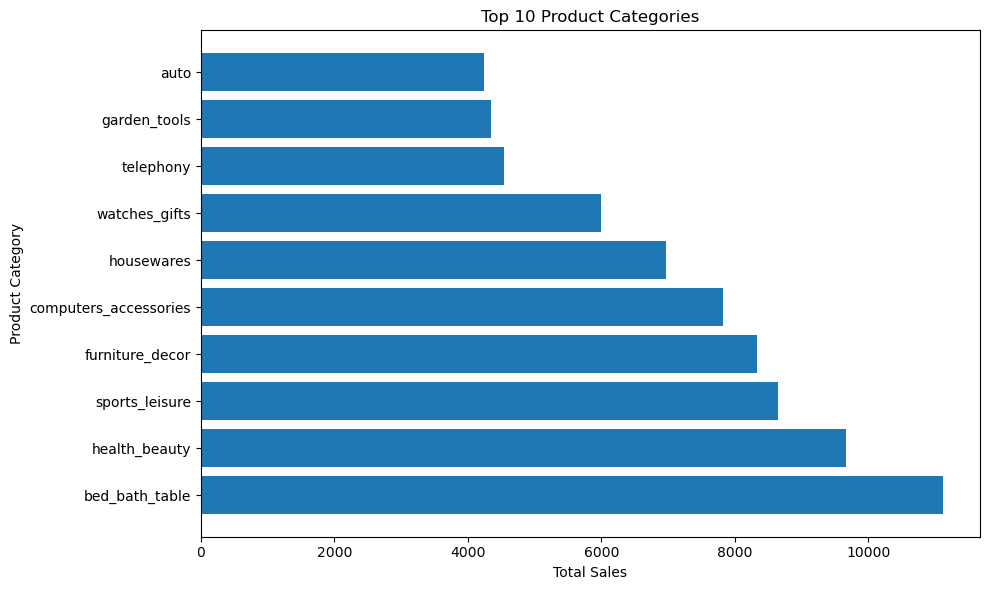

2026-06-17 11:49:17.562 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


PlotlyError: The `figure_or_data` positional argument must be `dict`-like, `list`-like, or an instance of plotly.graph_objs.Figure

In [29]:
query = """
SELECT
    t.product_category_name_english,
    COUNT(*) AS total_sales
FROM ecommerce_raw.order_items oi
JOIN ecommerce_raw.products p
    ON oi.product_id = p.product_id
JOIN ecommerce_raw.product_category_name_translation t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY total_sales DESC
LIMIT 10
"""

df = run_query(query)
fig = product_category_chart(df)
st.plotly_chart(fig, use_container_width=True)

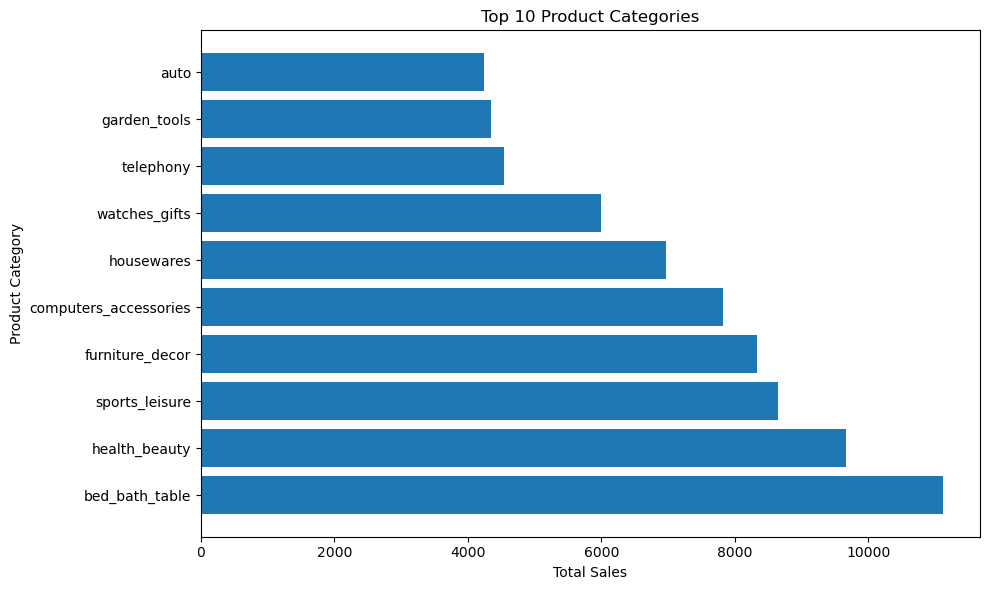

In [15]:
from charts import product_category_chart

product_category_chart(df)

In [16]:
query = """
SELECT
FORMAT_DATE('%Y-%m', DATE(order_purchase_timestamp)) AS month,
ROUND(SUM(payment_value),2) AS revenue
FROM ecommerce_raw.orders o
JOIN ecommerce_raw.order_payments p
ON o.order_id = p.order_id
WHERE order_status NOT IN ('canceled','unavailable')
GROUP BY month
ORDER BY month
"""

In [17]:
df = run_query(query)
df

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,revenue
0,2016-09,136.23
1,2016-10,51657.53
2,2016-12,19.62
3,2017-01,137006.76
4,2017-02,283621.94
5,2017-03,425656.40
6,2017-04,405988.38
7,2017-05,582926.16
8,2017-06,499827.47
9,2017-07,578858.58


In [18]:
query = """
SELECT
FORMAT_DATE('%Y-%m', DATE(order_purchase_timestamp)) AS month,
ROUND(SUM(payment_value),2) AS revenue
FROM ecommerce_raw.orders o
JOIN ecommerce_raw.order_payments p
ON o.order_id = p.order_id
WHERE order_status NOT IN ('canceled','unavailable')
AND DATE(order_purchase_timestamp) < '2018-09-01'
GROUP BY month
ORDER BY month
"""

In [19]:
df = run_query(query)

df.head()

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,revenue
0,2016-09,136.23
1,2016-10,51657.53
2,2016-12,19.62
3,2017-01,137006.76
4,2017-02,283621.94


In [20]:
import importlib
import charts

importlib.reload(charts)

from charts import monthly_revenue_chart

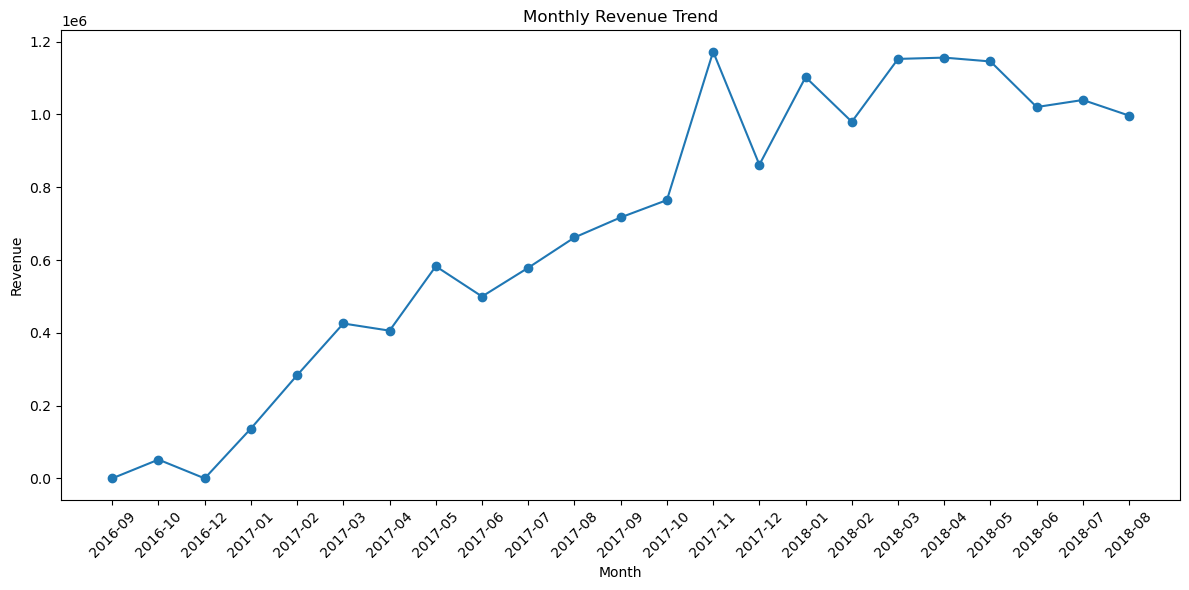

In [21]:
monthly_revenue_chart(df)

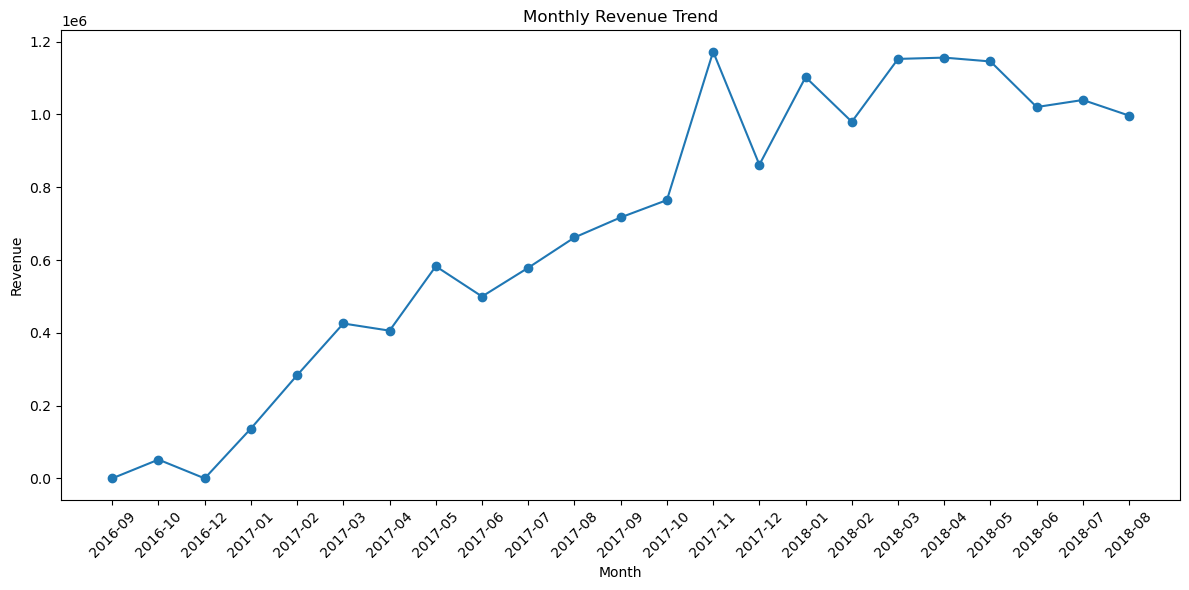

In [22]:
from charts import monthly_revenue_chart

monthly_revenue_chart(df)

In [23]:
query = """
SELECT
order_status,
COUNT(*) AS num_orders
FROM ecommerce_raw.orders
GROUP BY order_status
ORDER BY num_orders DESC
"""

df = run_query(query)

df

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_status,num_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


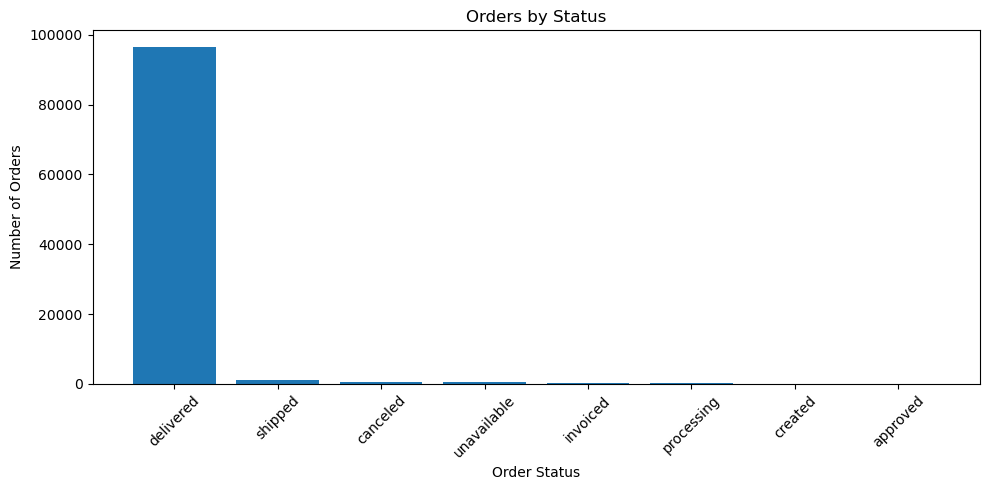

In [24]:
from charts import orders_status_chart

orders_status_chart(df)

In [25]:
query = """
SELECT *
FROM ecommerce_raw.products
LIMIT 5
"""

df = run_query(query)
df.columns

C:\Users\asus\New folder\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [26]:
query = """
SELECT *
FROM ecommerce_raw.product_category_name_translation
LIMIT 5
"""

df = run_query(query)
df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [30]:
answer = ask_gemini("What is business analytics?")

In [31]:
# test_ai.py

from ai_insights import generate_insight

print(
    generate_insight(
        "Total Revenue",
        "16 Million"
    )
)

Okay, with only "Total Revenue is 16 Million" as the data point, any insights will be high-level and will largely revolve around what *further questions* need to be asked.

Here are some business insights, framed around what this number *suggests* and what crucial *context* is missing:

**1. Acknowledging a Significant Milestone:**
*   **Insight:** At $16 million, the business has achieved a significant level of market traction and operational scale. This isn't a startup's revenue; it indicates an established product/service, a customer base, and a functioning sales and delivery mechanism.

**2. The Critical Need for Context:**
*   **Insight:** Without additional information, it's impossible to definitively judge whether $16 million is "good," "bad," or "average." This number is a starting point, not an end. The first step for deeper insights is always to ask:
    *   **Industry:** Is this a high-volume, low-margin industry (e.g., retail, manufacturing) or a high-margin, lower-volume i